# TT-31 — Lag + Rolling Features: dự báo phụ tải điện ngày mai

In [20]:
DATA_PATH = r"D:\TT_ML\TT-31-LagRolling_Linh\data\household_power_consumption.txt"
GIA_DIEN  = 2000        
N_HO      = 1_000_000   
TRAIN_END, VAL_END = "2008-12-31", "2009-12-31"   
OUT_DIR = "."     

import os, itertools, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
try:
    import holidays
except ImportError:
    holidays = None
    print("Không có thư viện 'holidays' -> bỏ cột ngày lễ (pip install holidays để bật)")

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
REP, MOD = os.path.join(OUT_DIR, "../reports"), os.path.join(OUT_DIR, "../models")
os.makedirs(REP, exist_ok=True); os.makedirs(MOD, exist_ok=True)

def mape(y, p): return float(np.mean(np.abs((y - p) / y)) * 100)
def score(y, p): return {"MAE": float(MAE(y, p)), "MAPE": mape(y, p)}
def bias(y, p):  return float(np.mean(p - y))

## Bước 1 — Đọc dữ liệu, ghép datetime, gộp về theo NGÀY
- `na_values="?"`: file UCI ghi giá trị thiếu bằng dấu `?`.
- `resample("D").mean()`: ~2 triệu dòng theo phút → ~1.440 dòng theo ngày (mean bỏ qua NaN).
- `asfreq("D")`: ép đủ mọi ngày liên tục; ngày thiếu hoàn toàn sẽ thành NaN (lỗ hổng thời gian).

In [21]:
raw = pd.read_csv(DATA_PATH, sep=";", na_values="?", low_memory=False)
raw["dt"] = pd.to_datetime(raw["Date"] + " " + raw["Time"], format="%d/%m/%Y %H:%M:%S")
s = raw.set_index("dt")["Global_active_power"].astype(float)
print(f"{len(s):,} dòng gốc | thiếu {s.isna().mean():.2%} | {s.index.min()} → {s.index.max()}")

daily = s.resample("D").mean().to_frame("phu_tai").asfreq("D")
daily.head()

2,075,259 dòng gốc | thiếu 1.25% | 2006-12-16 17:24:00 → 2010-11-26 21:02:00


,phu_tai
dt,
2006-12-16,3.053475
2006-12-17,2.354486
2006-12-18,1.530435
2006-12-19,1.157079
2006-12-20,1.545658


## Bước 2 — Xử lý thiếu + lỗ hổng, ghi lại % bị ảnh hưởng
Chỉ nội suy các lỗ **≤ 3 ngày**. Lỗ dài hơn giữ NaN (điền vào là bịa dữ liệu) — các dòng bị ảnh hưởng sẽ bị loại ở bước 5.

In [22]:
def fill_short_gaps(x, max_len=3):
    isna = x.isna()
    run_id = (isna != isna.shift()).cumsum()
    run_len = isna.groupby(run_id).transform("sum")
    filled = x.interpolate(limit_area="inside")
    return x.where(~(isna & (run_len <= max_len)), filled)

n = len(daily); n_thieu = int(daily["phu_tai"].isna().sum())
daily["bi_thieu"] = daily["phu_tai"].isna().astype(int)
daily["phu_tai"] = fill_short_gaps(daily["phu_tai"], 3)
print(f"Tổng {n} ngày | thiếu gốc {n_thieu} ({n_thieu/n:.2%}) | còn thiếu sau khi vá lỗ ngắn: {daily['phu_tai'].isna().sum()}")

Tổng 1442 ngày | thiếu gốc 9 (0.62%) | còn thiếu sau khi vá lỗ ngắn: 4


## Bước 3 — EDA: mùa vụ, thứ trong tuần, cuối tuần vs ngày thường

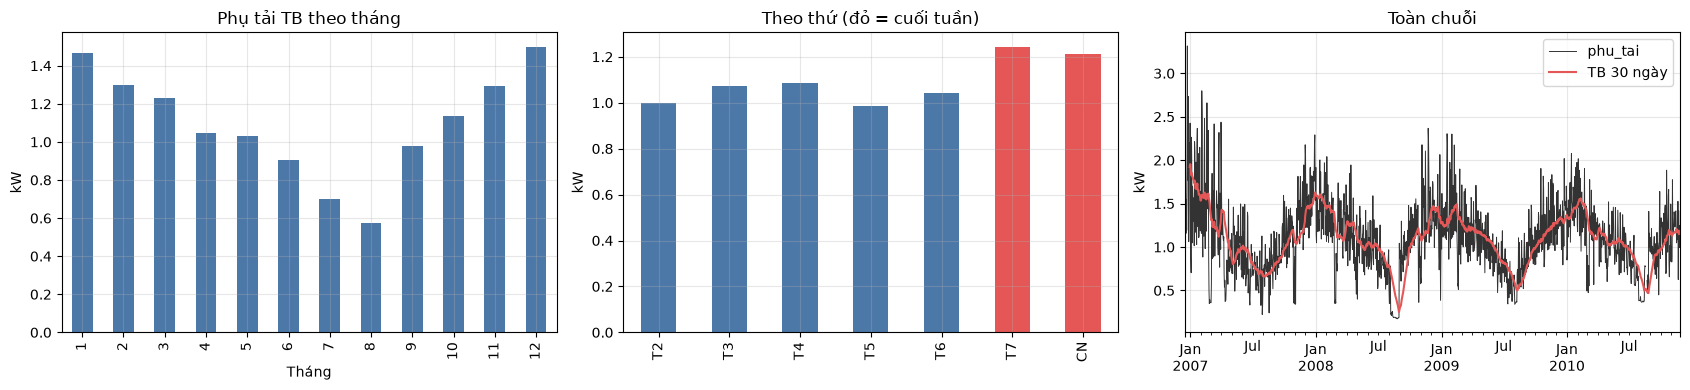

Cuối tuần 1.228 kW | ngày thường 1.038 kW | chênh +18.3%


In [23]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
daily["phu_tai"].groupby(daily.index.month).mean().plot(kind="bar", ax=ax[0], color="#4C78A8")
ax[0].set(title="Phụ tải TB theo tháng", xlabel="Tháng", ylabel="kW")
byd = daily["phu_tai"].groupby(daily.index.dayofweek).mean(); byd.index = ["T2","T3","T4","T5","T6","T7","CN"]
byd.plot(kind="bar", ax=ax[1], color=["#4C78A8"]*5 + ["#E45756"]*2)
ax[1].set(title="Theo thứ (đỏ = cuối tuần)", xlabel="", ylabel="kW")
daily["phu_tai"].plot(ax=ax[2], lw=.7, color="#333")
daily["phu_tai"].rolling(30, min_periods=15).mean().plot(ax=ax[2], color="#E45756", label="TB 30 ngày")
ax[2].set(title="Toàn chuỗi", xlabel="", ylabel="kW"); ax[2].legend()
plt.tight_layout(); plt.savefig(f"{REP}/eda_mua_vu.png"); plt.show()

wk = daily["phu_tai"][daily.index.dayofweek >= 5].mean(); wd = daily["phu_tai"][daily.index.dayofweek < 5].mean()
print(f"Cuối tuần {wk:.3f} kW | ngày thường {wd:.3f} kW | chênh {wk/wd-1:+.1%}")

## Bước 4 — Tạo đặc trưng lag + rolling + lịch
> 🚨 **Quy tắc số 1:** luôn `.shift(1)` **trước** `.rolling()`. Khi dự báo ngày *t* ta chỉ biết đến *t−1*. Tham số `leak=True` chỉ dùng cho thí nghiệm ở bước 9.

Tháng mã hoá bằng sin/cos để tháng 12 và tháng 1 nằm cạnh nhau.

In [24]:
LAGS, WINDOWS = [1, 2, 3, 7, 14, 30], [7, 14, 30]

def make_features(d, leak=False):
    d = d.copy(); y = d["phu_tai"]
    for lag in LAGS:
        d[f"lag_{lag}"] = y.shift(lag)
    base = y if leak else y.shift(1)          # <-- dòng quyết định
    for w in WINDOWS:
        r = base.rolling(w)
        d[f"tb_{w}"], d[f"std_{w}"] = r.mean(), r.std()
        d[f"max_{w}"], d[f"min_{w}"] = r.max(), r.min()
    d["thu"] = d.index.dayofweek
    d["cuoi_tuan"] = (d["thu"] >= 5).astype(int)
    d["thang_sin"] = np.sin(2*np.pi*d.index.month/12)
    d["thang_cos"] = np.cos(2*np.pi*d.index.month/12)
    if holidays is not None:                  # dữ liệu UCI là của Pháp
        fr = holidays.France(years=range(d.index.year.min(), d.index.year.max()+1))
        d["la_ngay_le"] = [int(x in fr) for x in d.index.date]
    return d

feat_all = make_features(daily)
FEATS = [c for c in feat_all.columns if c not in ("phu_tai", "bi_thieu")]
print(len(FEATS), "đặc trưng:", FEATS)

23 đặc trưng: ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'tb_7', 'std_7', 'max_7', 'min_7', 'tb_14', 'std_14', 'max_14', 'min_14', 'tb_30', 'std_30', 'max_30', 'min_30', 'thu', 'cuoi_tuan', 'thang_sin', 'thang_cos', 'la_ngay_le']


## Bước 5 — Xoá các dòng NaN

In [25]:
data = feat_all.dropna(subset=FEATS + ["phu_tai"])
print(f"{len(feat_all)} → {len(data)} dòng (loại {len(feat_all)-len(data)})")

1442 → 1378 dòng (loại 64)


## Bước 6 — Chia theo THỜI GIAN (không xáo trộn)
2006–2008 train · 2009 validation · 2010 test. Siêu tham số chọn trên val; test chỉ chạm **một lần** ở cuối.

In [26]:
train, val = data.loc[:TRAIN_END], data.loc[TRAIN_END:VAL_END].iloc[1:]
trval, test = data.loc[:VAL_END], data.loc[VAL_END:].iloc[1:]
Xtr, ytr = train[FEATS], train["phu_tai"]; Xva, yva = val[FEATS], val["phu_tai"]
Xtv, ytv = trval[FEATS], trval["phu_tai"]; Xte, yte = test[FEATS], test["phu_tai"]
print(f"train {len(train)} ({train.index.min().date()}→{train.index.max().date()}) | "
      f"val {len(val)} | test {len(test)} ({test.index.min().date()}→{test.index.max().date()})")

train 717 (2007-01-15→2008-12-31) | val 365 | test 296 (2010-01-01→2010-11-26)


## Bước 7 — Hai baseline
Model phải thắng được **seasonal naive**, nếu không thì không đáng triển khai.

In [27]:
res = {"Naive (hôm qua)": score(yte, Xte["lag_1"]),
       "Seasonal naive (tuần trước)": score(yte, Xte["lag_7"])}
pd.DataFrame(res).T.round(4)

,MAE,MAPE
Naive (hôm qua),0.2239,21.1921
Seasonal naive (tuần trước),0.2583,27.1846


## Bước 8 — Ridge · Random Forest · XGBoost → bảng so sánh
Chọn siêu tham số trên **val**, sau đó refit trên train+val và dự báo test.

In [28]:
def grid_search(build, grid):
    best, bp = np.inf, None
    for vals in itertools.product(*grid.values()):
        p = dict(zip(grid, vals)); m = build(**p).fit(Xtr, ytr)
        e = MAE(yva, m.predict(Xva))
        if e < best: best, bp = e, p
    return bp, best

builders = {
    "Ridge": (lambda alpha: make_pipeline(StandardScaler(), Ridge(alpha=alpha)), {"alpha": [0.1, 1, 10, 100]}),
    "RandomForest": (lambda min_samples_leaf, max_features: RandomForestRegressor(
        300, min_samples_leaf=min_samples_leaf, max_features=max_features, n_jobs=-1, random_state=0),
        {"min_samples_leaf": [3, 5], "max_features": [0.5, 1.0]}),
    "XGBoost": (lambda max_depth, n_estimators: XGBRegressor(
        n_estimators=n_estimators, learning_rate=0.03, max_depth=max_depth, subsample=.8,
        colsample_bytree=.8, random_state=0, n_jobs=-1), {"max_depth": [2, 3, 4], "n_estimators": [300, 600]}),
}
best_params, models, preds = {}, {}, {}
for name, (b, g) in builders.items():
    bp, ev = grid_search(b, g); best_params[name] = bp
    m = b(**bp).fit(Xtv, ytv)
    models[name] = m; preds[name] = pd.Series(m.predict(Xte), index=yte.index)
    res[name] = score(yte, preds[name])
    print(f"{name:13s} tham số {bp} | MAE val {ev:.4f}")

tab = pd.DataFrame(res).T.round(4); tab.to_csv(f"{REP}/bang_so_sanh.csv")
best_name = min(["Ridge", "RandomForest", "XGBoost"], key=lambda k: res[k]["MAE"])
sn = res["Seasonal naive (tuần trước)"]["MAE"]
print("\nMô hình tốt nhất:", best_name)
print("Thắng seasonal naive:", {k: res[k]["MAE"] < sn for k in ["Ridge", "RandomForest", "XGBoost"]})
models["XGBoost"].save_model(f"{MOD}/xgb_power.json")
tab

Ridge         tham số {'alpha': 100} | MAE val 0.1860
RandomForest  tham số {'min_samples_leaf': 5, 'max_features': 0.5} | MAE val 0.1865
XGBoost       tham số {'max_depth': 2, 'n_estimators': 300} | MAE val 0.1866

Mô hình tốt nhất: XGBoost
Thắng seasonal naive: {'Ridge': True, 'RandomForest': True, 'XGBoost': True}


,MAE,MAPE
Naive (hôm qua),0.2239,21.1921
Seasonal naive (tuần trước),0.2583,27.1846
Ridge,0.1917,20.7415
RandomForest,0.1856,19.6575
XGBoost,0.1793,18.3975


## Bước 9 — Thí nghiệm RÒ RỈ: cố tình quên `shift(1)`
Cùng XGBoost, cùng dữ liệu, chỉ khác đặc trưng rolling. Nếu MAE giảm một cách "đẹp bất thường" → nghi ngờ rò rỉ.

MAE đúng 0.1793 | MAE rò rỉ 0.1605 → giảm GIẢ TẠO 10.5%


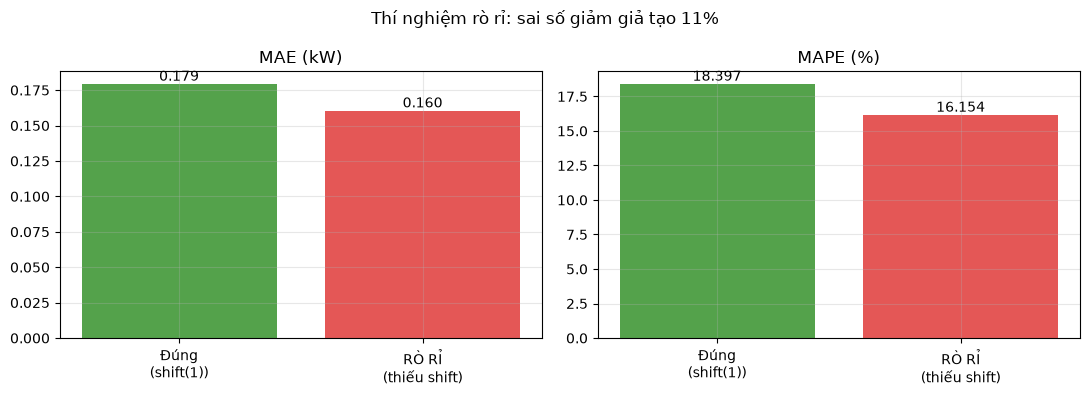

In [29]:
xp = best_params["XGBoost"]
mk = lambda: XGBRegressor(n_estimators=xp["n_estimators"], learning_rate=.03, max_depth=xp["max_depth"],
                          subsample=.8, colsample_bytree=.8, random_state=0, n_jobs=-1)
leaky = make_features(daily, leak=True).dropna(subset=FEATS + ["phu_tai"])
lk_tv, lk_te = leaky.loc[:VAL_END], leaky.loc[VAL_END:].iloc[1:]
lk = score(lk_te["phu_tai"], mk().fit(lk_tv[FEATS], lk_tv["phu_tai"]).predict(lk_te[FEATS]))
dung = res["XGBoost"]; giam = (1 - lk["MAE"] / dung["MAE"]) * 100
print(f"MAE đúng {dung['MAE']:.4f} | MAE rò rỉ {lk['MAE']:.4f} → giảm GIẢ TẠO {giam:.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, k, t in zip(ax, ["MAE", "MAPE"], ["MAE (kW)", "MAPE (%)"]):
    v = [dung[k], lk[k]]; bars = a.bar(["Đúng\n(shift(1))", "RÒ RỈ\n(thiếu shift)"], v, color=["#54A24B", "#E45756"]); a.set_title(t)
    for b_, x in zip(bars, v): a.text(b_.get_x()+b_.get_width()/2, x, f"{x:.3f}", ha="center", va="bottom")
fig.suptitle(f"Thí nghiệm rò rỉ: sai số giảm giả tạo {giam:.0f}%")
plt.tight_layout(); plt.savefig(f"{REP}/thi_nghiem_ro_ri.png"); plt.show()

## Bước 10 — Feature importance

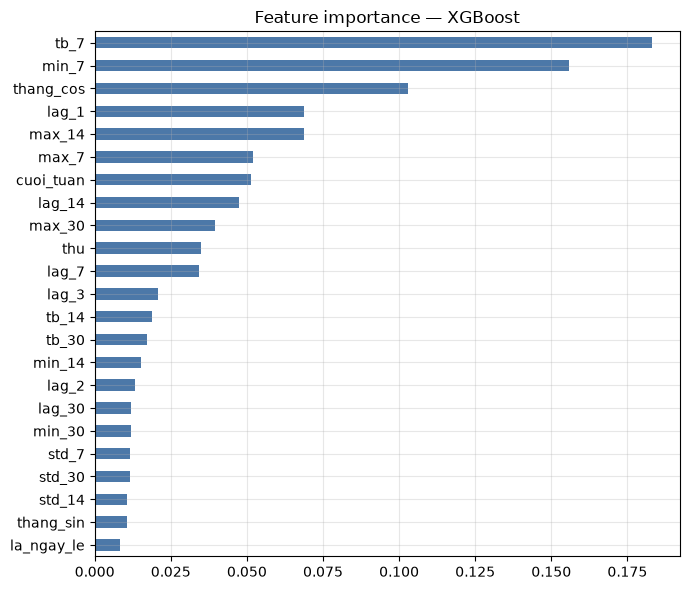

tb_7         0.183
min_7        0.156
thang_cos    0.103
lag_1        0.069
max_14       0.069
dtype: float32


In [30]:
imp = pd.Series(models["XGBoost"].feature_importances_, index=FEATS).sort_values()
plt.figure(figsize=(7, 6)); imp.plot(kind="barh", color="#4C78A8"); plt.title("Feature importance — XGBoost")
plt.tight_layout(); plt.savefig(f"{REP}/feature_importance.png"); plt.show()
print(imp.sort_values(ascending=False).head(5).round(3))

## Bước 11 — Thí nghiệm NGOẠI SUY: dự đoán tuyệt đối vs chênh lệch
Cây không dự đoán vượt khoảng giá trị đã thấy khi train. Dự đoán `y − lag` rồi cộng lại giúp cây xử lý xu hướng. Cột `bias` âm = dự báo thấp hơn thực tế.

TB phụ tải: train 1.085 → val 1.076 → test 1.079 kW


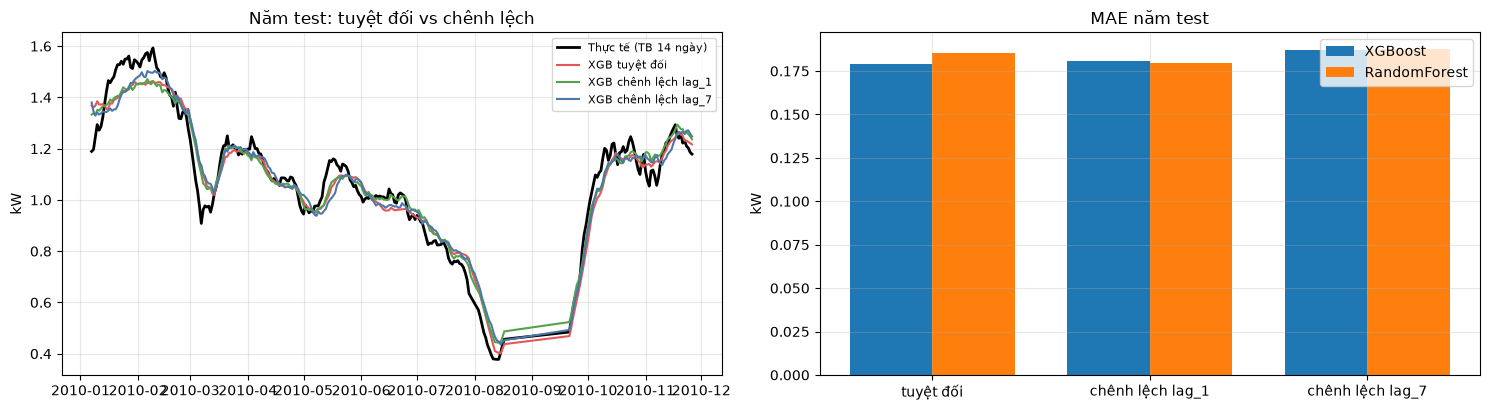

,MAE,MAPE,bias
XGBoost | tuyệt đối,0.1793,18.3975,-0.0044
XGBoost | chênh lệch lag_1,0.1806,18.6217,0.0024
XGBoost | chênh lệch lag_7,0.1869,19.5619,0.0030
RandomForest | tuyệt đối,0.1856,19.6575,0.0037
RandomForest | chênh lệch lag_1,0.1798,18.4645,0.0077
RandomForest | chênh lệch lag_7,0.1879,19.4656,-0.0002


In [31]:
ext = {}
for mname in ["XGBoost", "RandomForest"]:
    for tag, base in [("tuyệt đối", None), ("chênh lệch lag_1", "lag_1"), ("chênh lệch lag_7", "lag_7")]:
        m = builders[mname][0](**best_params[mname])
        if base is None:
            m.fit(Xtv, ytv); p = pd.Series(m.predict(Xte), index=yte.index)
        else:
            m.fit(Xtv, ytv - Xtv[base]); p = pd.Series(m.predict(Xte), index=yte.index) + Xte[base]
        ext[(mname, tag)] = p
ext_tab = pd.DataFrame({f"{k[0]} | {k[1]}": {**score(yte, p), "bias": bias(yte, p)} for k, p in ext.items()}).T
print(f"TB phụ tải: train {ytr.mean():.3f} → val {yva.mean():.3f} → test {yte.mean():.3f} kW")

fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
w = yte.rolling(14, min_periods=7).mean(); ax[0].plot(w.index, w, "k", lw=2, label="Thực tế (TB 14 ngày)")
for tag, c in [("tuyệt đối", "#E45756"), ("chênh lệch lag_1", "#54A24B"), ("chênh lệch lag_7", "#4C78A8")]:
    ax[0].plot(w.index, ext[("XGBoost", tag)].rolling(14, min_periods=7).mean(), c=c, label=f"XGB {tag}")
ax[0].set(title="Năm test: tuyệt đối vs chênh lệch", ylabel="kW"); ax[0].legend(fontsize=8)
tags = ["tuyệt đối", "chênh lệch lag_1", "chênh lệch lag_7"]; x = np.arange(3)
for i, mn in enumerate(["XGBoost", "RandomForest"]):
    ax[1].bar(x + (i-.5)*.38, [ext_tab.loc[f"{mn} | {t}", "MAE"] for t in tags], .38, label=mn)
ax[1].set_xticks(x); ax[1].set_xticklabels(tags); ax[1].set(title="MAE năm test", ylabel="kW"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{REP}/ngoai_suy.png"); plt.show()
ext_tab.round(4)

## Bước 12 — Dự báo vs thực tế, 60 ngày cuối

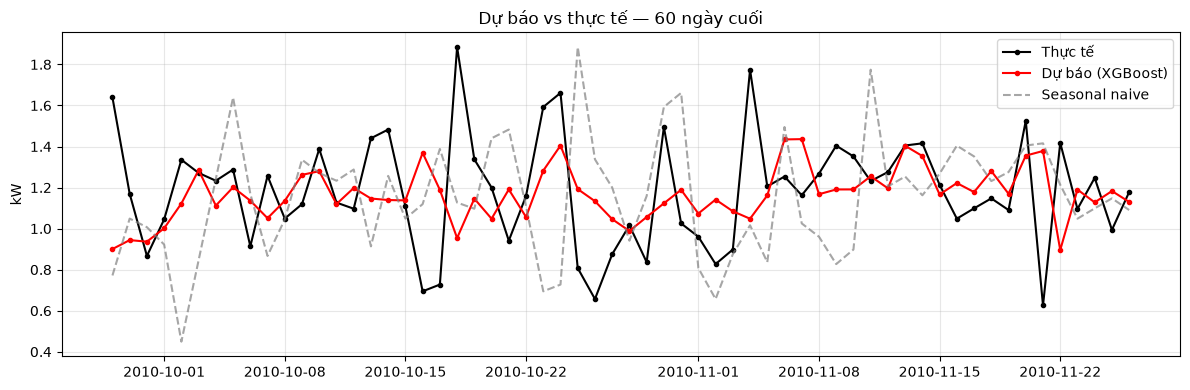

In [32]:
bp_ = preds[best_name]
plt.figure(figsize=(12, 4))
plt.plot(yte.index[-60:], yte.iloc[-60:], "k-o", ms=3, label="Thực tế")
plt.plot(yte.index[-60:], bp_.iloc[-60:], "r-o", ms=3, label=f"Dự báo ({best_name})")
plt.plot(yte.index[-60:], Xte["lag_7"].iloc[-60:], "--", c="gray", alpha=.7, label="Seasonal naive")
plt.title("Dự báo vs thực tế — 60 ngày cuối"); plt.ylabel("kW"); plt.legend()
plt.tight_layout(); plt.savefig(f"{REP}/du_bao_60_ngay.png"); plt.show()

## Bước 13 — TimeSeriesSplit (KHÔNG dùng KFold thường)
Mỗi fold train trên quá khứ, validate trên đoạn ngay sau đó.

In [33]:
folds = []
for tr, va in TimeSeriesSplit(n_splits=5).split(Xtv):
    m = mk().fit(Xtv.iloc[tr], ytv.iloc[tr]); folds.append(float(MAE(ytv.iloc[va], m.predict(Xtv.iloc[va]))))
print("MAE từng fold:", np.round(folds, 4)); print(f"Trung bình {np.mean(folds):.4f} ± {np.std(folds):.4f}")

MAE từng fold: [0.2303 0.2022 0.2437 0.2054 0.1655]
Trung bình 0.2094 ± 0.0269


## Bước 14 — Quy đổi sai số ra TIỀN
`MAE (kW trung bình) × 24h = kWh/ngày`, nhân giá điện. Dữ liệu là 1 hộ nên số nhỏ — kịch bản hệ thống chỉ là phép nhân minh hoạ dựa trên giả định `N_HO`.

In [34]:
mae_kw = res[best_name]["MAE"]; kwh = mae_kw * 24
print(f"Mô hình {best_name}: MAE {mae_kw:.4f} kW → {kwh:.2f} kWh/ngày/hộ")
print(f"≈ {kwh*GIA_DIEN:,.0f} VND/ngày/hộ | {kwh*GIA_DIEN*365:,.0f} VND/năm/hộ  (giá {GIA_DIEN} VND/kWh)")
print(f"Kịch bản {N_HO:,} hộ giống nhau ≈ {kwh*GIA_DIEN*N_HO*365/1e9:,.1f} tỷ VND/năm (giả định, minh hoạ)")

Mô hình XGBoost: MAE 0.1793 kW → 4.30 kWh/ngày/hộ
≈ 8,607 VND/ngày/hộ | 3,141,432 VND/năm/hộ  (giá 2000 VND/kWh)
Kịch bản 1,000,000 hộ giống nhau ≈ 3,141.4 tỷ VND/năm (giả định, minh hoạ)
